In [3]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from tabulate import tabulate
from wordcloud import WordCloud
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

#import nltk
#nltk.download('stopwords')
from nltk.corpus import stopwords

#pd.set_option('display.max_rows', None)

Chargement des données

MOVIES : liste des films et leur genre

In [4]:
movies = pd.read_csv('movies.csv')

# Remplacement du genre (no genres listed) par NaN
movies['genres'] = movies['genres'].replace('(no genres listed)', np.nan)

# Séparation des genres en listes
movies = movies.join(
    movies['genres'].str.get_dummies(sep='|').add_prefix('genre_')
)

movies = movies.drop(columns=['genres'])

display(movies.head(2))

movies.info()

,movieId,title,genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,...,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western
0,1,Toy Story (1995),0,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<class 'pandas.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   movieId            27278 non-null  int64
 1   title              27278 non-null  str  
 2   genre_Action       27278 non-null  int64
 3   genre_Adventure    27278 non-null  int64
 4   genre_Animation    27278 non-null  int64
 5   genre_Children     27278 non-null  int64
 6   genre_Comedy       27278 non-null  int64
 7   genre_Crime        27278 non-null  int64
 8   genre_Documentary  27278 non-null  int64
 9   genre_Drama        27278 non-null  int64
 10  genre_Fantasy      27278 non-null  int64
 11  genre_Film-Noir    27278 non-null  int64
 12  genre_Horror       27278 non-null  int64
 13  genre_IMAX         27278 non-null  int64
 14  genre_Musical      27278 non-null  int64
 15  genre_Mystery      27278 non-null  int64
 16  genre_Romance      27278 non-null  int64
 17  genre_Sci-Fi       2727

In [5]:
# titres de film en doublon
dup_titles = movies[movies.duplicated(subset='title', keep=False)].sort_values('title')
display(dup_titles[['movieId', 'title']])

,movieId,title
24064,114130,"20,000 Leagues Under the Sea (1997)"
20923,102190,"20,000 Leagues Under the Sea (1997)"
582,588,Aladdin (1992)
24092,114240,Aladdin (1992)
24437,115777,Beneath (2013)
21429,104035,Beneath (2013)
13417,66140,Blackout (2007)
16827,85070,Blackout (2007)
26808,128862,Casanova (2005)
10694,42015,Casanova (2005)


RATINGS : notes des films par les utilisateurs

In [6]:
ratings = pd.read_csv('ratings.csv')

ratings = ratings.drop(columns=['timestamp'])

display(ratings.head(2))
ratings.info(show_counts=True)

,userId,movieId,rating
0,1,2,3.5
1,1,29,3.5


<class 'pandas.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 3 columns):
 #   Column   Non-Null Count     Dtype  
---  ------   --------------     -----  
 0   userId   20000263 non-null  int64  
 1   movieId  20000263 non-null  int64  
 2   rating   20000263 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 457.8 MB


TAGS : tag des films par les utilisateurs

In [7]:
tags = pd.read_csv('tags.csv')

tags = tags.drop(columns=['timestamp'])
tags = tags.dropna()

display(tags.head(2))
tags.info()

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero


<class 'pandas.DataFrame'>
Index: 465548 entries, 0 to 465563
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   userId   465548 non-null  int64
 1   movieId  465548 non-null  int64
 2   tag      465548 non-null  str  
dtypes: int64(2), str(1)
memory usage: 14.2 MB


In [10]:
# nombre de movieId uniques dans tags
tags['movieId'].nunique()

19545

SCORE MOVIE : GENOME SCORES & GENOME TAGS

In [8]:
genome_scores = pd.read_csv('genome-scores.csv')
genome_tags = pd.read_csv('genome-tags.csv')

display(genome_scores.head(2))
display(genome_tags.head(2))
display(genome_scores.info(show_counts=True))
genome_tags.info()

,movieId,tagId,relevance
0,1,1,0.025
1,1,2,0.025


,tagId,tag
0,1,007
1,2,007 (series)


<class 'pandas.DataFrame'>
RangeIndex: 11709768 entries, 0 to 11709767
Data columns (total 3 columns):
 #   Column     Non-Null Count     Dtype  
---  ------     --------------     -----  
 0   movieId    11709768 non-null  int64  
 1   tagId      11709768 non-null  int64  
 2   relevance  11709768 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 268.0 MB


None

<class 'pandas.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   tagId   1128 non-null   int64
 1   tag     1128 non-null   str  
dtypes: int64(1), str(1)
memory usage: 17.8 KB


**********************************************************************

Filtrage basé sur le contenu : on utilise l'information qu'on connaît sur les intérêts des utilisateurs comme liaison pour les recommandations potentielles. Ces intérêts sont dans le dataframe TAG

**********************************************************************

--> TOKENIZATION et VECTORISATION : processus qui consiste à diviser un texte en unités individuelles appelées des tokens. La vectorisation consiste à représenter chaque token sous forme numérique 

1ere modèle : on utilise les tags des utilisateurs, et on détermine les films similaires

In [9]:
# Dans le dataframe TAG nous avons plusieurs lignes pour un film, soit une ligne par tag. On va regrouper les tags en une seule ligne par film
tagsMovie = (
    tags
    .groupby('movieId')['tag']
    .apply(lambda x: ' '.join(x.astype(str)))
    .reset_index()
)
display(tagsMovie.head(2))
tagsMovie.shape

,movieId,tag
0,1,Watched computer animation Disney animated fea...
1,2,time travel adapted from:book board game child...


(19545, 2)

In [10]:
# ajout du titre du film
tagsMovie = tagsMovie.merge(movies[['movieId', 'title']], on='movieId', how='left')
display(tagsMovie.head(2))
tagsMovie.shape

,movieId,tag,title
0,1,Watched computer animation Disney animated fea...,Toy Story (1995)
1,2,time travel adapted from:book board game child...,Jumanji (1995)


(19545, 3)

Nombre de mots dans les tags :  5597776
Nombre de mots après filtrage :  3507410


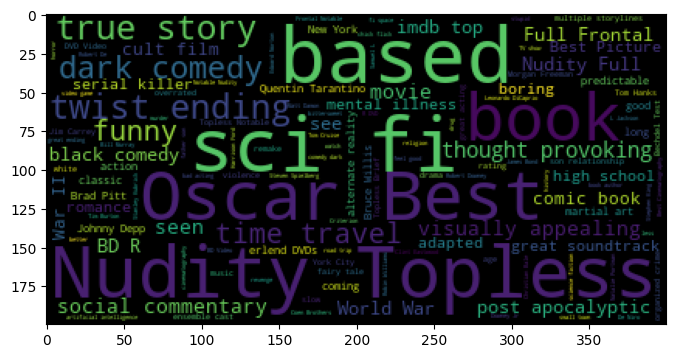

In [11]:
# affichage des mots dominants dans les tags des films

text = ""
for tg in tagsMovie.tag : 
    text += tg

print("Nombre de mots dans les tags : ", len(text))

stop_words = set(stopwords.words('english'))
#stop_words.update([",", ".", ":", "-"])

tokens = [mot for mot in text if mot not in stop_words]
print("Nombre de mots après filtrage : ", len(tokens))

# Définir le calque du nuage des mots
wc = WordCloud(background_color="black", max_words=1000, stopwords=stop_words, max_font_size=50, random_state=42)
# Générer et afficher le nuage de mots
plt.figure(figsize= (8,6)) # Initialisation d'une figure
wc.generate(text)           # "Calcul" du wordcloud
plt.imshow(wc) # Affichage
plt.show()

In [13]:
# tokenization et vectorisation des tags
# création d'un TfidfVectorizer et suppression des mots vides
tfidf = TfidfVectorizer(stop_words='english')
# Adapter et transformer les données en une matrice tfidf
matrice_tfidf = tfidf.fit_transform(tagsMovie['tag'])
print(matrice_tfidf.shape)
# on a 19545 films et 23863 mots importants après avoir enlevé les mots vides

# similarité des films
# On calcule la similarité cosinus
sim_cosinus = cosine_similarity(matrice_tfidf, matrice_tfidf)

# On calcule la similarité euclidienne
# On rappelle que dans la mesure euclidienne plus la distance est courte, plus la similitude est élevée. Pour garantir que des valeurs plus élevées correspondent à une plus grande similarité (convention courante dans les systèmes de recommandation) on fait la transformation
sim_euclidienne = 1 / (1 + euclidean_distances(matrice_tfidf))

(19545, 23863)


In [14]:
# indices indexés par movieId (unique) → pas de collision sur les titres dupliqués
indices = pd.Series(range(0, len(tagsMovie)), index=tagsMovie['movieId'])

# Mapping titre → liste de movieIds pour gérer les titres dupliqués dans movies
titre_vers_ids = tagsMovie.groupby('title')['movieId'].apply(list)

def rechercher_par_titre(titre):
    """Retourne le movieId correspondant au titre.
    Si plusieurs films partagent le même titre, affiche les options et retourne la liste."""
    if titre not in titre_vers_ids.index:
        print(f"Aucun film trouvé pour '{titre}'")
        return None
    ids = titre_vers_ids[titre]
    if len(ids) == 1:
        return ids[0]
    print(f"Plusieurs films trouvés pour '{titre}' (titre dupliqué) :")
    for mid in ids:
        print(f"  movieId={mid} → {titre}")
    print("Appelez recommander_films(movie_id) avec le movieId souhaité.")
    return ids

# Fonction de recommandation basée sur la similarité cosinus (ou euclidienne)
def recommander_films(movie_id, mat_sim=sim_cosinus, num_recommendations=10):
    # Récupérer la position dans la matrice TF-IDF via movieId (clé unique)
    idx = indices[movie_id]
    titre_film = tagsMovie.loc[tagsMovie['movieId'] == movie_id, 'title'].values[0]

    # Obtenir et trier les scores de similarité
    scores_similarite = sorted(
        enumerate(mat_sim[idx]), key=lambda x: x[1], reverse=True
    )

    # Top N films similaires (hors le film lui-même)
    top_similair = scores_similarite[1:num_recommendations + 1]
    res = [(tagsMovie.iloc[i]['title'], score) for i, score in top_similair]

    return tabulate(res, headers=["Titre", "Score de similarité"], tablefmt="pretty")

# Aperçu de l'index
#display(indices.head(2))

In [19]:
# recherche d'un exemple de titre à tester
tagsMovie.loc[tagsMovie['title'].str.contains("superman", case=False, na=False), 'title']

2178                                       Superman (1978)
2179                                    Superman II (1980)
2180                                   Superman III (1983)
2181               Superman IV: The Quest for Peace (1987)
7976                     Batman/Superman Movie, The (1998)
9484                               Superman Returns (2006)
13091                   Superman/Batman: Apocalypse (2010)
13209                          Waiting for Superman (2010)
13592                             All-Star Superman (2011)
14333                     Superman and the Mole-Men (1951)
15058                        Superman vs. The Elite (2012)
15064                            Superman/Doomsday (2007) 
15081               Superman/Batman: Public Enemies (2009)
15994    Look, Up in the Sky! The Amazing Story of Supe...
16182                              Superman Unbound (2013)
Name: title, dtype: str

In [21]:
# test
exple_titre = 'Superman (1978)'
#exple_titre = 'Batman: The Dark Knight Returns, Part 1 (2012)'
#exple_titre = 'Aladdin (1992)'
movie_id = rechercher_par_titre(exple_titre)

"""on vérifie si la variable est de type entier (int), et donc on affiche les recommandations
sinon on choisit la première occurence de la liste et on affiche les recommandations
"""
if isinstance(movie_id, int):
    print(f"Recommandations pour {exple_titre} (movieId={movie_id}) similarité cosinus :\n",
          recommander_films(movie_id, sim_cosinus))
    print(f"\nRecommandations pour {exple_titre} (movieId={movie_id}) similarité euclidienne :\n",
          recommander_films(movie_id, sim_euclidienne))
else:
    # Si plusieurs films partagent le même titre, on prend le premier movieId de la liste
    first_movie_id = movie_id[0]
    print(f"Recommandations pour {exple_titre} (movieId={first_movie_id}) similarité cosinus :\n",
          recommander_films(first_movie_id, sim_cosinus))
    print(f"\nRecommandations pour {exple_titre} (movieId={first_movie_id}) similarité euclidienne :\n",
          recommander_films(first_movie_id, sim_euclidienne))


Recommandations pour Superman (1978) (movieId=2640) similarité cosinus :
 +-----------------------------------------+---------------------+
|                  Titre                  | Score de similarité |
+-----------------------------------------+---------------------+
|           Superman II (1980)            | 0.7478048539793456  |
|              X-Men (2000)               | 0.6790540093470957  |
| Superman IV: The Quest for Peace (1987) | 0.6592746563221346  |
|              Spawn (1997)               | 0.6505405062628266  |
|         X2: X-Men United (2003)         | 0.6325677616151166  |
|           Superman III (1983)           | 0.6091471459787986  |
|            Spider-Man (2002)            |  0.607950880887924  |
|           Spider-Man 2 (2004)           | 0.6062066958731267  |
|           Spider-Man 3 (2007)           | 0.5468416290214296  |
|               Hulk (2003)               | 0.5398430775744109  |
+-----------------------------------------+---------------------+

R

2eme modèle : on utilise les genome tags, et on détermine les films similaires

In [22]:
# Fusion genome_scores + genome_tags pour obtenir les noms des tags
genome = genome_scores.merge(genome_tags, on='tagId', how='left')

# Seuil de pertinence : on ne garde que les tags vraiment représentatifs du film
# La pertinence (relevance) est comprise entre 0 et 1
SEUIL_PERTINENCE = 0.5

# Pour chaque film : concaténation des tags dont la pertinence >= seuil
genomeMovie = (
    genome[genome['relevance'] >= SEUIL_PERTINENCE]
    .groupby('movieId')['tag']
    .apply(lambda x: ' '.join(x.astype(str)))
    .reset_index()
)

# Ajout du titre du film (gestion des doublons : movieId est la clé unique)
genomeMovie = genomeMovie.merge(movies[['movieId', 'title']], on='movieId', how='left')

print(f"Films couverts par genome (seuil={SEUIL_PERTINENCE}) : {len(genomeMovie)}")
display(genomeMovie.head(2))


Films couverts par genome (seuil=0.5) : 10381


,movieId,tag,title
0,1,3d action adventure affectionate animal movie ...,Toy Story (1995)
1,2,action adapted from:book adventure animal movi...,Jumanji (1995)


In [23]:
# Vectorisation TF-IDF sur les tags genome
tfidf_genome = TfidfVectorizer(stop_words='english')
matrice_tfidf_genome = tfidf_genome.fit_transform(genomeMovie['tag'])
print(f"Matrice genome : {matrice_tfidf_genome.shape}  "
      f"({matrice_tfidf_genome.shape[0]} films × {matrice_tfidf_genome.shape[1]} tokens)")

# Similarité cosinus
sim_cosinus_genome = cosine_similarity(matrice_tfidf_genome, matrice_tfidf_genome)

# Similarité euclidienne (inversée pour que plus grand = plus similaire)
sim_euclidienne_genome = 1 / (1 + euclidean_distances(matrice_tfidf_genome))


Matrice genome : (10381, 1124)  (10381 films × 1124 tokens)


In [24]:
# Index par movieId (unique) — même logique que le modèle 1
indices_genome = pd.Series(range(len(genomeMovie)), index=genomeMovie['movieId'])

# Mapping titre → liste de movieIds pour gérer les titres dupliqués
titre_vers_ids_genome = genomeMovie.groupby('title')['movieId'].apply(list)

def rechercher_par_titre_genome(titre):
    """Résout un titre en movieId(s). Gère les doublons de titres."""
    if titre not in titre_vers_ids_genome.index:
        print(f"Aucun film trouvé pour '{titre}'")
        return None
    ids = titre_vers_ids_genome[titre]
    if len(ids) == 1:
        return ids[0]
    print(f"Plusieurs films trouvés pour '{titre}' (titre dupliqué) :")
    for mid in ids:
        print(f"  movieId={mid} → {titre}")
    print("Appelez recommander_films_genome(movie_id) avec le movieId souhaité.")
    return ids

def recommander_films_genome(movie_id, mat_sim=sim_cosinus_genome, num_recommendations=10):
    idx = indices_genome[movie_id]
    scores_similarite = sorted(
        enumerate(mat_sim[idx]), key=lambda x: x[1], reverse=True
    )
    top_similair = scores_similarite[1:num_recommendations + 1]
    res = [(genomeMovie.iloc[i]['title'], score) for i, score in top_similair]
    return tabulate(res, headers=["Titre", "Score de similarité"], tablefmt="pretty")

display(indices_genome.head(2))


movieId
1    0
2    1
dtype: int64

In [25]:
# test — même titre que le modèle 1 pour comparer les résultats
exple_titre_genome = exple_titre
movie_id_genome = rechercher_par_titre_genome(exple_titre_genome)

if isinstance(movie_id_genome, int):
    print(f"Recommandations genome pour {exple_titre_genome} (movieId={movie_id_genome}) cosinus :\n",
          recommander_films_genome(movie_id_genome, sim_cosinus_genome))
    print(f"\nRecommandations genome pour {exple_titre_genome} (movieId={movie_id_genome}) euclidienne :\n",
          recommander_films_genome(movie_id_genome, sim_euclidienne_genome))


Recommandations genome pour Superman (1978) (movieId=2640) cosinus :
 +--------------------------------+---------------------+
|             Titre              | Score de similarité |
+--------------------------------+---------------------+
|       Superman II (1980)       | 0.8061716046488677  |
|          X-Men (2000)          | 0.7693996284331363  |
|      Man of Steel (2013)       | 0.7578926942492213  |
|    X2: X-Men United (2003)     | 0.7540091410064353  |
|          Thor (2011)           | 0.7478578112794325  |
|      Avengers, The (2012)      | 0.7384722385723371  |
|       Spider-Man (2002)        | 0.7306460733332996  |
| Guardians of the Galaxy (2014) | 0.7257721653472382  |
|      Green Lantern (2011)      | 0.7163877649890025  |
|  Thor: The Dark World (2013)   | 0.7140139493597656  |
+--------------------------------+---------------------+

Recommandations genome pour Superman (1978) (movieId=2640) euclidienne :
 +--------------------------------+---------------------+


Vérification des recommandations avec le clustering sur la base des films

In [26]:
# créons un dataframe qui contient movies, en mettant movieId comme index, ensuite en supprimmant title
mv = tagsMovie.set_index('movieId')
mv = mv.drop(columns=['title'])
mv

def preprocess(text):
    text = text.lower()
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    return " ".join(tokens)

mv['tags_clean'] = mv['tag'].apply(preprocess)
display(mv.head(3))
#mv = mv.drop(columns=['tags'])
#tfidf_cl = TfidfVectorizer(max_features=5000)
tfidf_cl = TfidfVectorizer()
tfidf_matrix_cl = tfidf_cl.fit_transform(mv['tags_clean'])

,tag,tags_clean
movieId,,
1,Watched computer animation Disney animated fea...,watched computer animation disney animated fea...
2,time travel adapted from:book board game child...,time travel adapted from:book board game child...
3,old people that is actually funny sequel fever...,old people actually funny sequel fever grun ru...


In [27]:
# recherche du k optimal pour le clustering KMeans
range_n_clusters = range(5, 100)
distortions = []
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(tfidf_matrix_cl)
    distortions.append(kmeans.inertia_)  # inertia_ fonctionne sur les matrices sparse
    print(f"Distortion for {n_clusters} clusters: {distortions[-1]:.4f}")


Distortion for 5 clusters: 18763.2810
Distortion for 6 clusters: 18493.5266
Distortion for 7 clusters: 18576.6674
Distortion for 8 clusters: 18210.5361
Distortion for 9 clusters: 18141.6856
Distortion for 10 clusters: 18104.0775
Distortion for 11 clusters: 18004.5664
Distortion for 12 clusters: 17860.4338
Distortion for 13 clusters: 17833.7949
Distortion for 14 clusters: 17788.5197
Distortion for 15 clusters: 17750.7853
Distortion for 16 clusters: 17798.1998
Distortion for 17 clusters: 17716.5012
Distortion for 18 clusters: 17699.0722
Distortion for 19 clusters: 17667.2529
Distortion for 20 clusters: 17642.7023
Distortion for 21 clusters: 17585.4984
Distortion for 22 clusters: 17534.7193
Distortion for 23 clusters: 17520.2318
Distortion for 24 clusters: 17514.9422
Distortion for 25 clusters: 17505.9673
Distortion for 26 clusters: 17459.9015
Distortion for 27 clusters: 17428.2188
Distortion for 28 clusters: 17406.3169
Distortion for 29 clusters: 17466.0464
Distortion for 30 clusters: 17

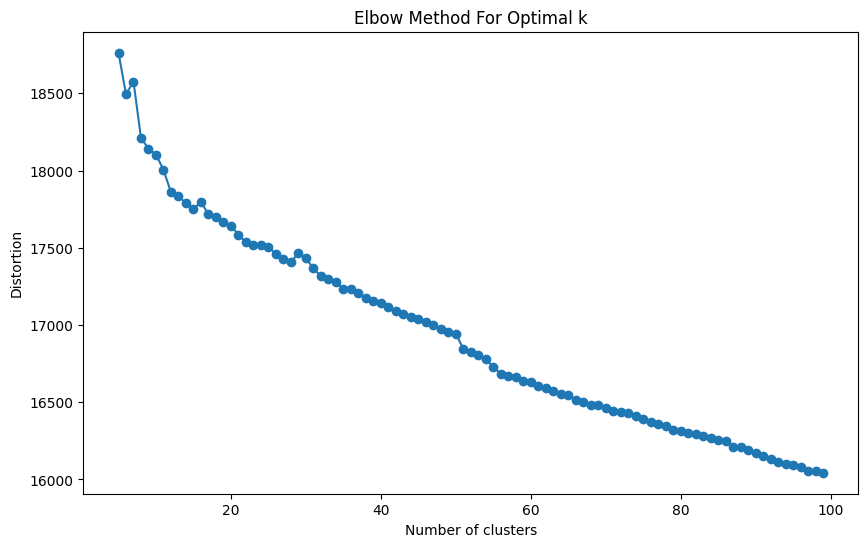

In [28]:
# affichage du graphique de l'Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, distortions, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

In [29]:
# nous allons partir sur 50 clusters, car c'est le point où la courbe commence à se stabiliser (le "coude" de la courbe).   
kmeans = KMeans(n_clusters=50, random_state=42)
kmeans.fit(tfidf_matrix_cl)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",50
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [30]:
# a partir d'un movieId movie_id, on va pouvoir retrouver le cluster auquel il appartient, puis les autres films du même cluster
def recommander_films_cluster(movie_id, num_recommendations=50):
    # Récupérer la position dans la matrice TF-IDF via movieId (clé unique)
    idx = indices[movie_id]
    titre_film = tagsMovie.loc[tagsMovie['movieId'] == movie_id, 'title'].values[0]

    # Obtenir le cluster du film
    cluster_label = kmeans.labels_[idx]

    # Obtenir les indices des films dans le même cluster
    indices_cluster = np.where(kmeans.labels_ == cluster_label)[0]

    # Exclure le film lui-même
    indices_cluster = indices_cluster[indices_cluster != idx]

    # Limiter aux N recommandations
    top_indices = indices_cluster[:num_recommendations]

    res = [(tagsMovie.iloc[i]['title'], kmeans.labels_[i]) for i in top_indices]

    return tabulate(res, headers=["Titre", "Cluster"], tablefmt="pretty")

# affichons les films du même cluster que le film exemple
if isinstance(movie_id, int):
    print(f"Recommandations cluster pour {exple_titre} (movieId={movie_id}) :\n",
          recommander_films_cluster(movie_id))  
else:
    # Si plusieurs films partagent le même titre, on prend le premier movieId de la liste
    first_movie_id = movie_id[0]
    print(f"Recommandations cluster pour {exple_titre} (movieId={first_movie_id}) :\n",                                                                   
          recommander_films_cluster(first_movie_id))

    

Recommandations cluster pour Superman (1978) (movieId=2640) :
 +--------------------------------------------------------------------------------+---------+
|                                     Titre                                      | Cluster |
+--------------------------------------------------------------------------------+---------+
|                                Bad Boys (1995)                                 |   48    |
|                             Batman Forever (1995)                              |   48    |
|                                  Crumb (1994)                                  |   48    |
|                                Desperado (1995)                                |   48    |
|                       Die Hard: With a Vengeance (1995)                        |   48    |
|                      Under Siege 2: Dark Territory (1995)                      |   48    |
|                                Crow, The (1994)                                |   48    |
|      

cette fois il faut être capablee de construire des clusters d'utilisateurs afin de faire des recommandations. nous allons nous baser sur les genone tags

In [30]:
# Model de filtrage du contenu
print("Model de filtrage du contenu")

Model de filtrage du contenu
